# Iris Flower Classification for Beginners Using Descision Treee and Random Forest

## Practical Machine Learning Laboratory

**Algorithms Covered**

- Decision Tree
- Random Forest

This practical notebook teaches machine learning **step by step**. Every section explains **what we are doing, why we are doing it, and what the output means** before writing any code.

**Dataset:** `Iris.csv`


## Learning Objectives

By the end of this lab, you should be able to:

- Understand what a machine learning classification problem is.
- Load and explore a dataset using Pandas.
- Identify features and the target variable.
- Prepare data for machine learning.
- Split data into training and testing sets.
- Train a Decision Tree classifier.
- Train a Random Forest classifier.
- Compare the performance of both models.
- Interpret feature importance and evaluation results.


## What is the Iris Dataset?

The Iris dataset is one of the most famous datasets in machine learning.

It contains measurements of **150 iris flowers** belonging to **three different species**:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

Each flower has four measurements:

| Feature | Meaning |
|---------|---------|
| SepalLengthCm | Length of the sepal |
| SepalWidthCm | Width of the sepal |
| PetalLengthCm | Length of the petal |
| PetalWidthCm | Width of the petal |

Our goal is to teach the computer to **predict the species of a flower** from these measurements.


## Machine Learning Workflow

We will follow the same workflow used in many real-world projects.

1. Import libraries.
2. Load the dataset.
3. Explore the data.
4. Prepare the data.
5. Split into training and testing sets.
6. Train a Decision Tree.
7. Evaluate the Decision Tree.
8. Train a Random Forest.
9. Evaluate the Random Forest.
10. Compare both models.


## Step 1: Import the Libraries
Libraries are collections of ready-made Python code that help us work faster.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### What each library does

- **Pandas** – Works with tables of data.
- **Matplotlib** – Draws graphs.
- **train_test_split** – Splits data into training and testing sets.
- **LabelEncoder** – Converts text labels into numbers.
- **DecisionTreeClassifier** – Builds a Decision Tree model.
- **RandomForestClassifier** – Builds many Decision Trees together.
- **Metrics** – Measures model performance.


## Step 2: Load the Dataset
A **DataFrame** is a table with rows and columns.

In [21]:
df = pd.read_csv("students_dataset.csv")

print("Number of rows and columns:", df.shape)
df.head()

Number of rows and columns: (600, 5)


,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,61.22,29.73,86.57,3.17,Class_B
1,49.52,30.18,90.28,4.39,Class_A
2,65.90,39.07,70.51,2.28,Class_A
3,76.36,27.33,63.87,2.04,Class_B
4,55.15,25.03,78.91,2.82,Class_A


### Understanding the output

- **Rows** represent individual flowers.
- **Columns** represent measurements.
- `head()` shows the first five rows so we can check that the data loaded correctly.


## Step 3: Explore the Dataset
Before building a model, always understand your data.

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  600 non-null    float64
 1   Feature_2  600 non-null    float64
 2   Feature_3  600 non-null    float64
 3   Feature_4  600 non-null    float64
 4   Target     600 non-null    str    
dtypes: float64(4), str(1)
memory usage: 23.6 KB


`info()` tells us:

- Number of rows
- Number of columns
- Data types
- Missing values


In [23]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4
count,600.000000,600.000000,600.000000,600.000000
mean,64.489933,29.924467,101.094917,2.678467
std,12.154783,7.777202,32.018631,1.857127
min,28.080000,5.840000,36.030000,-2.570000
25%,56.392500,24.817500,74.617500,1.387500
50%,63.765000,29.975000,94.610000,2.665000
75%,73.305000,35.285000,125.687500,3.870000
max,101.480000,55.100000,186.520000,9.020000


`describe()` calculates useful statistics such as:

- Mean
- Minimum
- Maximum
- Standard deviation


In [22]:
df.isnull().sum()

Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Target       0
dtype: int64

This checks whether any column has missing values.

## Step 4: Visualize the Data
Graphs help us understand patterns.

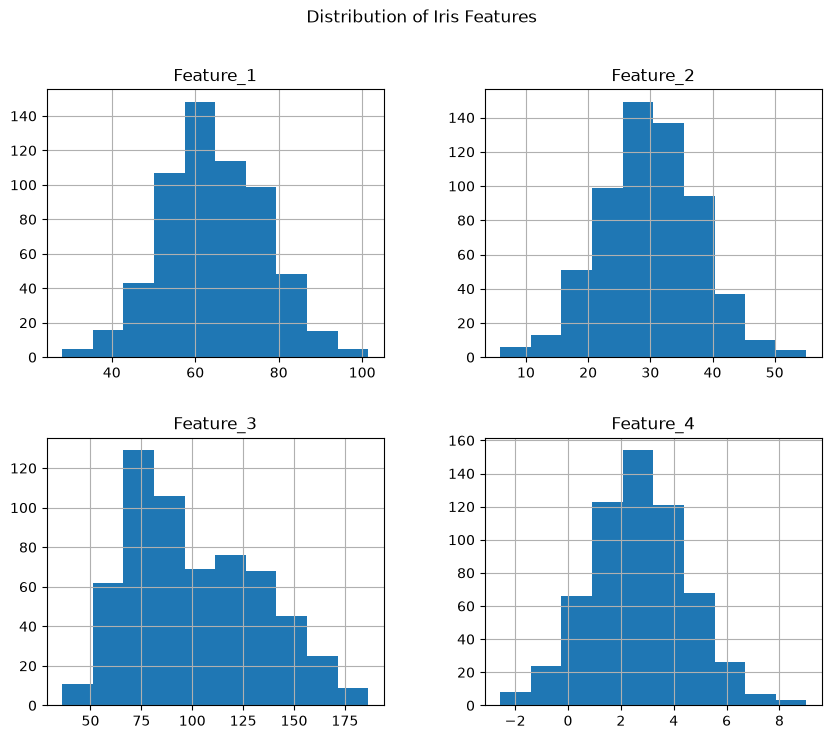

In [24]:
df.hist(figsize=(10,8))
plt.suptitle("Distribution of Iris Features")
plt.show()

These histograms show how values are distributed for each measurement.

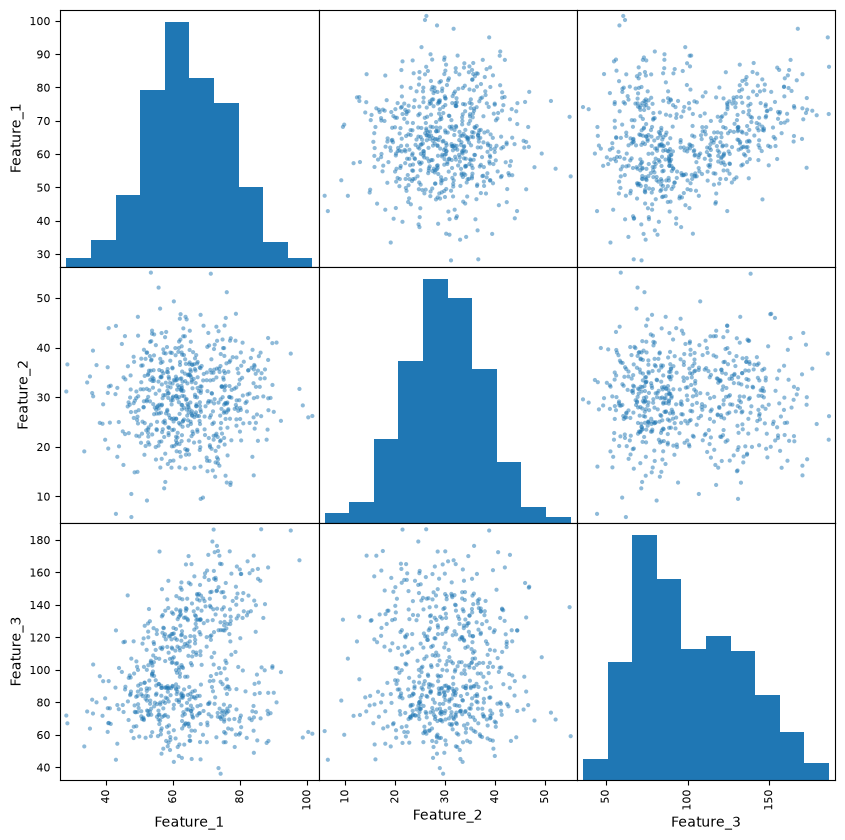

In [24]:
pd.plotting.scatter_matrix(
    df.drop(columns="Feature_4"),
    figsize=(10,10),
    diagonal="hist"
)
plt.show()

The scatter matrix helps us see relationships between features.

Notice that **Petal Length** and **Petal Width** separate the flower species quite clearly.


## Step 5: Prepare the Data

Machine learning models work with numbers, so we need to prepare the dataset.

### What we will do

1. Remove the `Id` column.
2. Convert `Species` into numbers.
3. Create **features (X)**.
4. Create the **target (y)**.


In [25]:
data = df.copy()

data = data.drop(columns="Feature_1")

encoder = LabelEncoder()
data["Species"] = encoder.fit_transform(data["Feature_2"])

X = data.drop("Species", axis=1)
y = data["Species"]

print("Feature columns:", list(X.columns))
print("Target classes:", list(encoder.classes_))

Feature columns: ['Feature_2', 'Feature_3', 'Feature_4', 'Target']
Target classes: [np.float64(5.84), np.float64(6.48), np.float64(9.17), np.float64(9.5), np.float64(9.76), np.float64(10.49), np.float64(11.63), np.float64(12.31), np.float64(12.77), np.float64(12.79), np.float64(12.91), np.float64(13.97), np.float64(14.17), np.float64(14.24), np.float64(14.85), np.float64(14.95), np.float64(15.07), np.float64(15.23), np.float64(15.59), np.float64(15.77), np.float64(15.79), np.float64(15.82), np.float64(15.85), np.float64(16.01), np.float64(16.19), np.float64(16.34), np.float64(16.53), np.float64(16.7), np.float64(16.85), np.float64(17.14), np.float64(17.19), np.float64(17.22), np.float64(17.43), np.float64(17.49), np.float64(17.57), np.float64(17.82), np.float64(17.86), np.float64(17.98), np.float64(18.03), np.float64(18.26), np.float64(18.39), np.float64(18.4), np.float64(18.45), np.float64(18.61), np.float64(18.96), np.float64(19.07), np.float64(19.09), np.float64(19.18), np.float64(1

### Features vs Target

- **Features (X):** Information used to make predictions.
- **Target (y):** The answer the model tries to predict.


## Step 6: Split the Dataset

We divide the dataset into two parts.

| Dataset | Purpose |
|---------|---------|
| Training Data | Used for learning |
| Testing Data | Used for evaluation |

We use **80% for training** and **20% for testing**.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42

)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 480
Testing samples: 120


## Step 7: Train a Decision Tree

A Decision Tree makes predictions by asking a series of questions.

Example:

- Is Petal Length less than a certain value?
- Is Sepal Width greater than another value?

These questions create branches until a final prediction is reached.


In [11]:
decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

decision_tree.fit(X_train, y_train)

# dt_predictions = decision_tree.predict(X_test)

# dt_accuracy = accuracy_score(y_test, dt_predictions)

# print("Decision Tree Accuracy:", dt_accuracy)

NameError: name 'X_train' is not defined

### View the Decision Tree

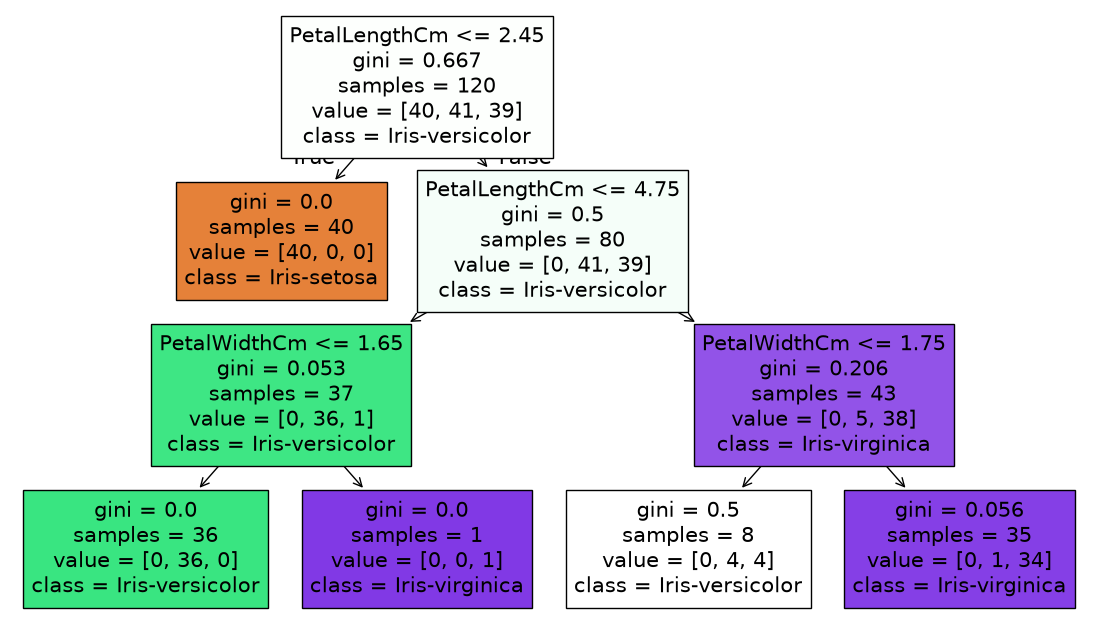

In [16]:
plt.figure(figsize=(14,8))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True
)

plt.show()

The colors represent different flower species, and each box shows the rule used to split the data.


### Evaluate the Decision Tree

Random Forest is a supervised machine learning algorithm used for both classification (predicting categories such as Yes/No, Spam/Not Spam) and regression (predicting numerical values such as house prices). It belongs to the family of ensemble learning algorithms because it combines multiple models—in this case, many Decision Trees—to produce a single, more accurate prediction.

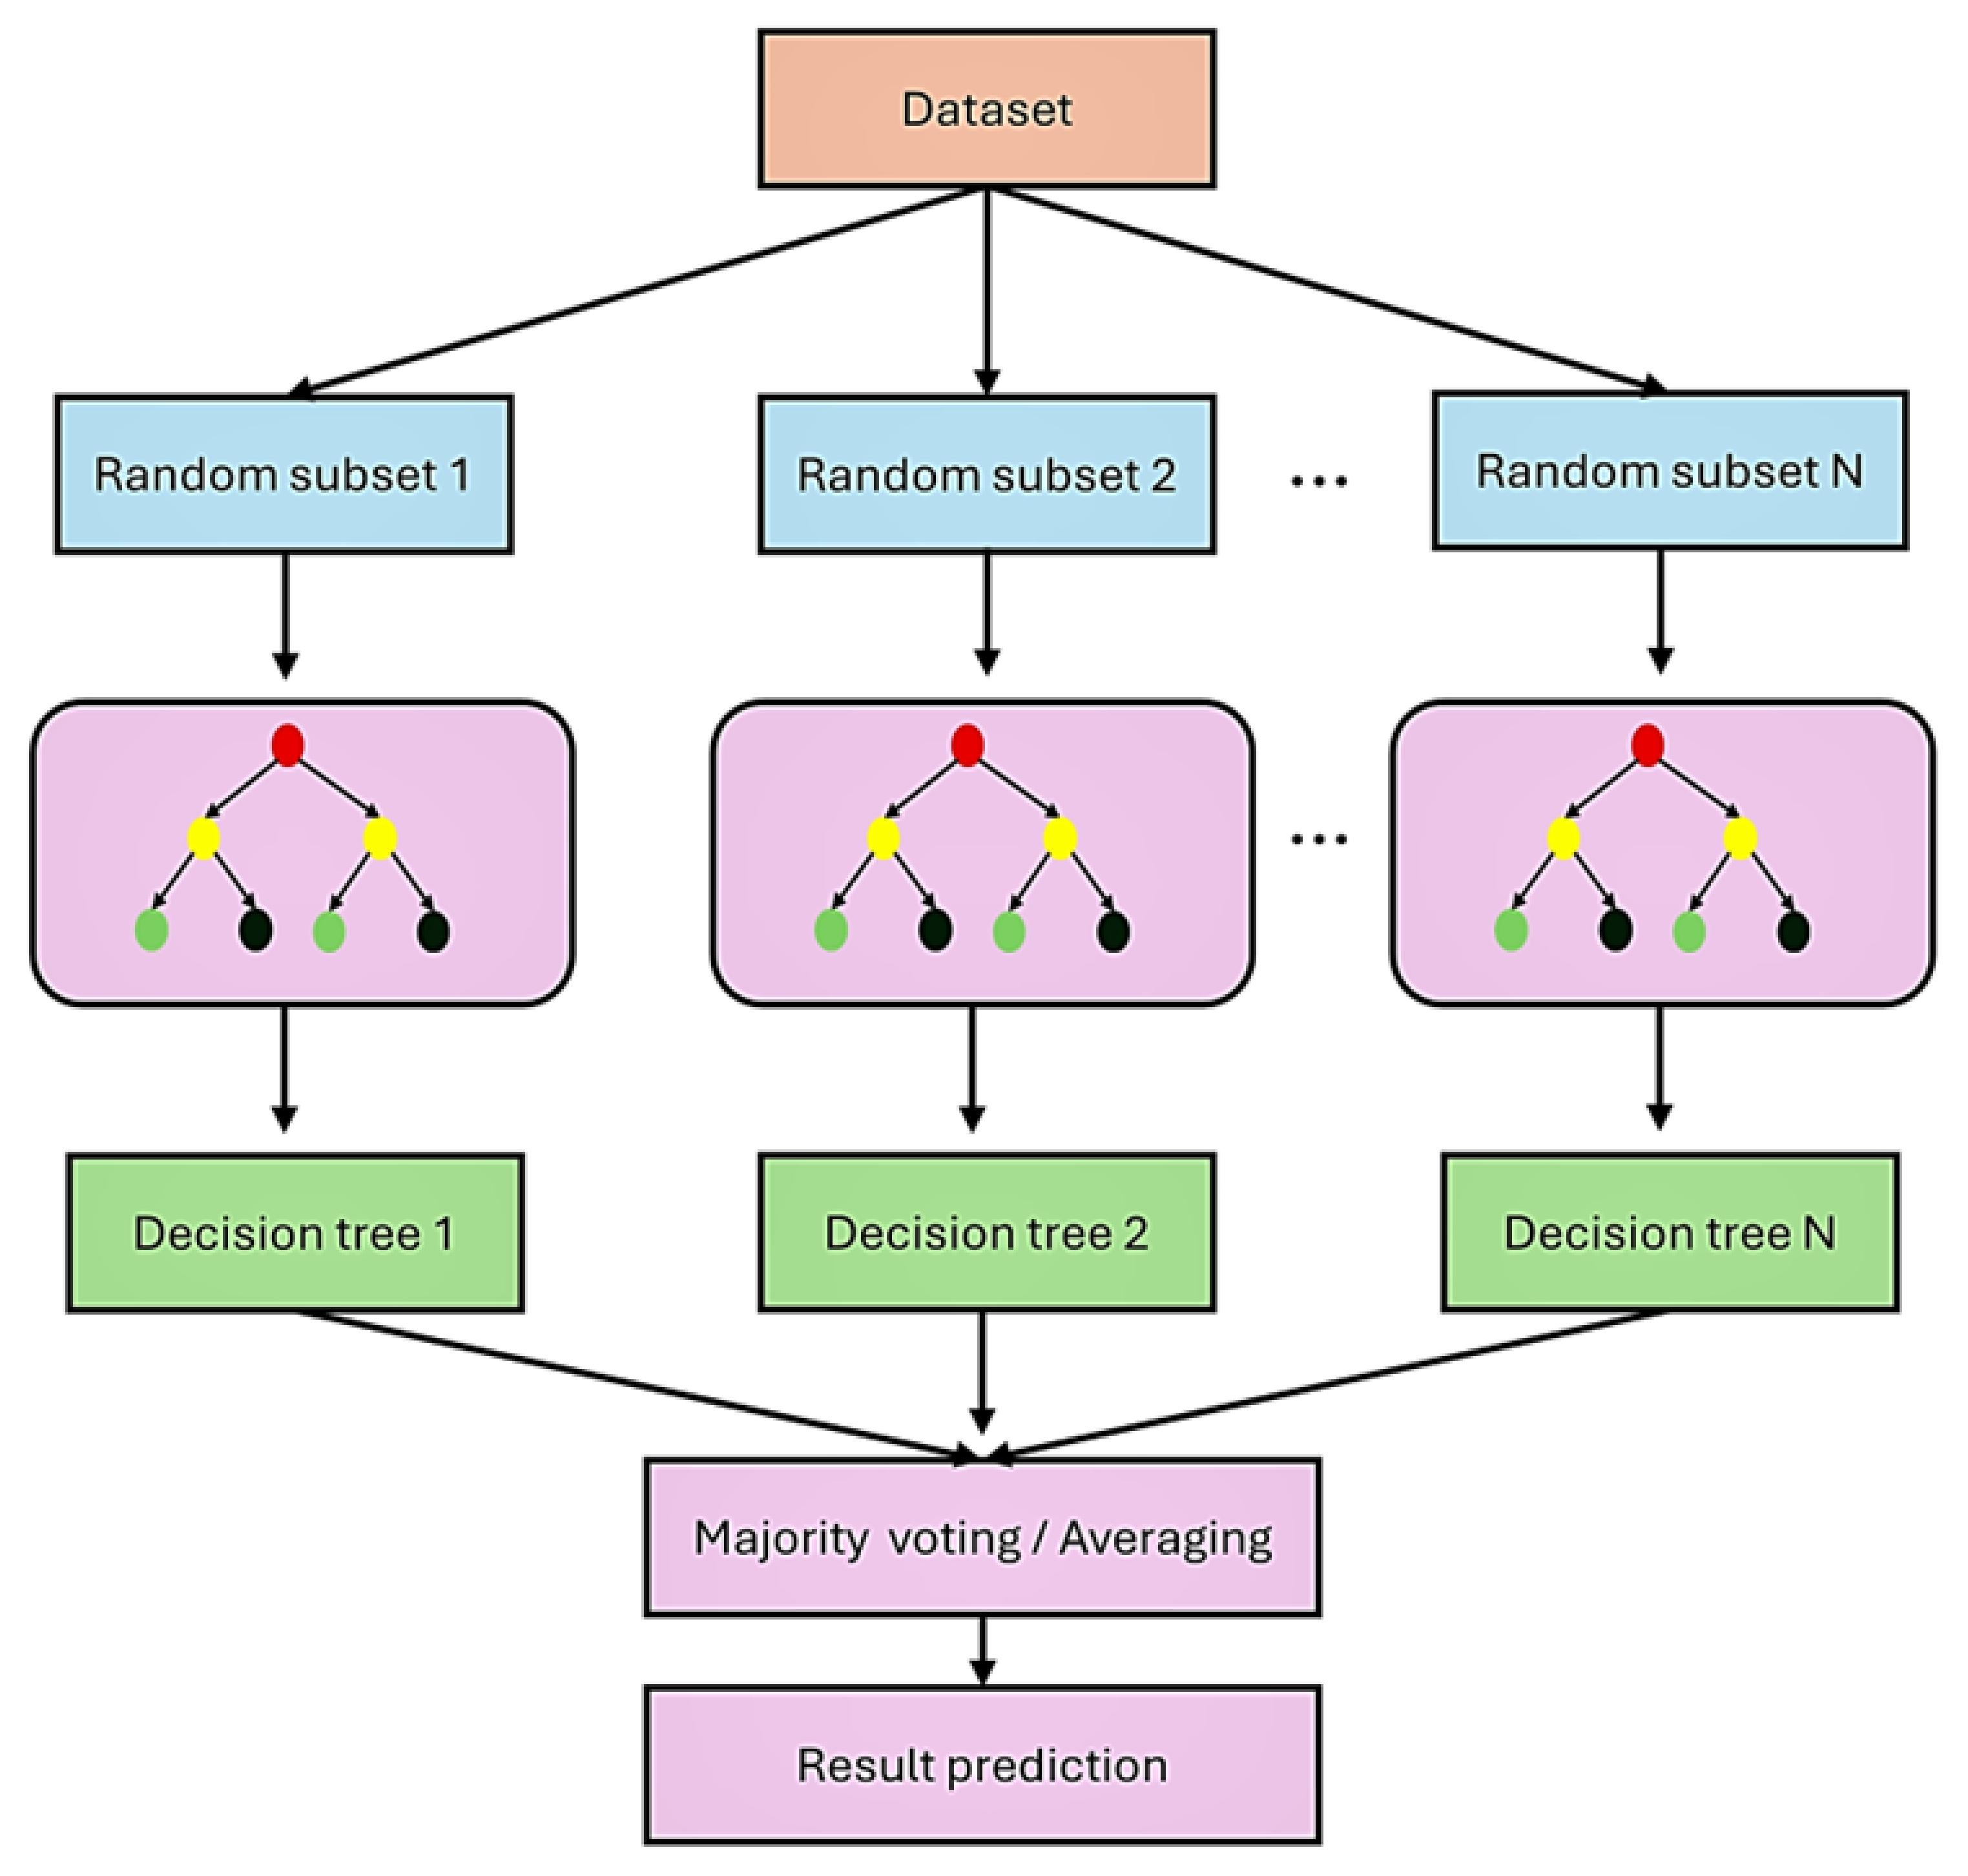

In [17]:
print(classification_report(
    y_test,
    dt_predictions,
    target_names=encoder.classes_
))

print("Confusion Matrix")
print(confusion_matrix(y_test, dt_predictions))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### Understanding the Evaluation

- **Accuracy** – Percentage of correct predictions.
- **Precision** – Correct positive predictions.
- **Recall** – How many real examples were found.
- **F1-score** – Balance between Precision and Recall.

The confusion matrix shows where mistakes happened.


## Step 8: Train a Random Forest

A Random Forest builds **many Decision Trees** instead of only one.

Each tree learns from a slightly different sample of the data, and they vote for the final answer.

This usually produces more reliable predictions.


In [18]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


### Evaluate the Random Forest

In [19]:
print(classification_report(
    y_test,
    rf_predictions,
    target_names=encoder.classes_
))

print("Confusion Matrix")
print(confusion_matrix(y_test, rf_predictions))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### Feature Importance

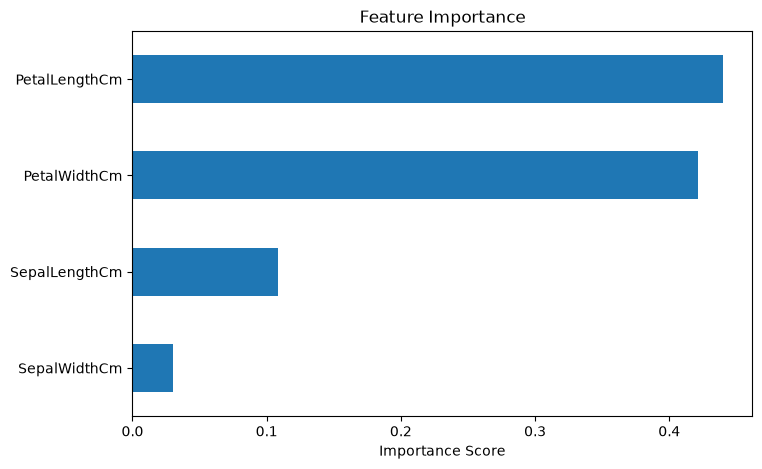

In [20]:
importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

Feature Importance tells us which measurements influenced predictions the most.


## Step 9: Compare Both Models

Now we compare the two algorithms using their accuracy scores.


           Model  Accuracy
0  Decision Tree       1.0
1  Random Forest       1.0


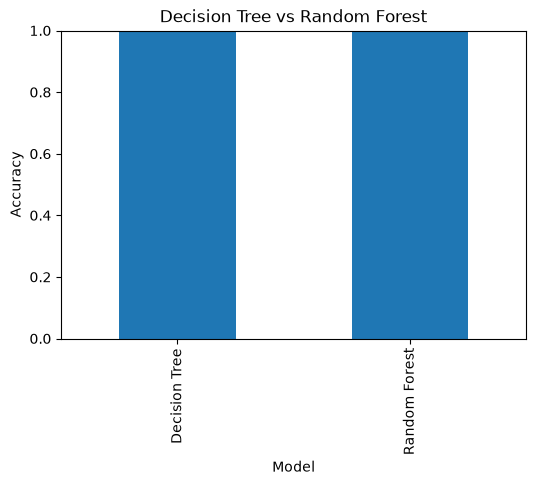

In [21]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

print(results)

results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Decision Tree vs Random Forest")
plt.show()

## Which Model Performed Better?

In many cases:

- Decision Tree performs well and is easy to understand.
- Random Forest often performs slightly better because it combines many trees.


## Summary Table

| Feature | Decision Tree | Random Forest |
|---------|--------------:|--------------:|
| Number of Trees | 1 | 100 |
| Easy to Visualize | Yes | No |
| Easy to Explain | Yes | Moderate |
| Usually More Accurate | Good | Better |
| Risk of Overfitting | Higher | Lower |


## Key Takeaways

- We solved a **classification** problem.
- The Iris dataset contains four flower measurements.
- We separated **features** from the **target**.
- We trained two different models.
- We evaluated both models using accuracy and classification reports.
- Random Forest usually improves prediction by combining many Decision Trees.


## Practice Exercises

1. Change `max_depth` from **3** to **2** and **5**.
2. Increase `n_estimators` from **100** to **200**.
3. Which feature has the highest importance?
4. Which model would you choose for this dataset? Explain why.
5. Try changing `test_size` from **0.20** to **0.30**. Does the accuracy change?
